## 00: Core Libraries for Computer Vision in PyTorch

Here are the essential PyTorch libraries and modules commonly used for computer vision tasks:

*   `torch` module: The foundational PyTorch library for efficient tensor operations and building deep learning models.
*   `torch.nn` module: Provides the building blocks (layers, activation functions) for constructing and defining neural network architectures.
*   `torchvision`: A comprehensive package specifically designed for computer vision, offering convenient access to datasets, pre-trained models, and image transformations.
*   `torchvision.datasets`: Contains implementations of popular computer vision datasets (e.g., MNIST, CIFAR10, ImageNet) ready for use in training and evaluation.
*   `torchvision.transforms`: A collection of utility functions to preprocess and augment image data, preparing it for neural networks (e.g., resizing, cropping, normalization).
*   `torchvision.models`: Offers a variety of pre-trained neural network models (e.g., ResNet, VGG, AlexNet) that can be used for transfer learning or as feature extractors.
*   `torch.utils.data.Dataset`: An abstract class that represents a collection of samples, providing an interface for creating custom datasets in PyTorch.
*   `torch.utils.data.DataLoader`: An iterator that efficiently loads data from a `Dataset` in mini-batches, handles shuffling, and supports multi-process data loading.

In [1]:
# Importing torch
import torch
from torch import nn

#importing torchvision
import torchvision
from torchvision import datasets
import torchvision.transforms
from torchvision.transforms import ToTensor

#Importing Visualization tool
import matplotlib.pyplot as plt


torch.__version__, torchvision.__version__




('2.11.0+cu128', '0.26.0+cu128')

## 01: Preparing the FashionMNIST Dataset

**FashionMNIST** is a dataset of Zalando's article images, consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes of clothing items (e.g., T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot). It is intended as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms. Like MNIST, it is readily available through `torchvision.datasets`.

In [2]:
train_data = torchvision.datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform = ToTensor(),
    target_transform=None
     )

test_data = torchvision.datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.4MB/s]


In [3]:
len(train_data), len(test_data)
image, label = train_data[0]

###01.1: Input and output shapes of a computer vision model

In [4]:
image.shape, label

(torch.Size([1, 28, 28]), 9)

In [5]:
# How many samples are there?
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [6]:
class_name = train_data.classes
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

###01.2 Visualizing our data

Text(0.5, 1.0, '9')

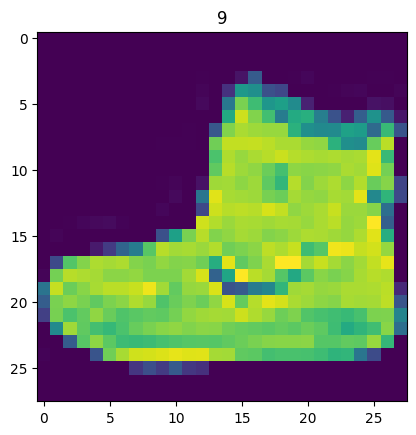

In [7]:
plt.imshow(image.squeeze())
plt.title(label)

Text(0.5, 1.0, 'Ankle boot')

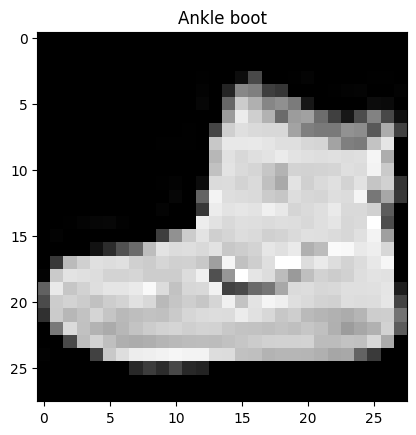

In [8]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_name[label])

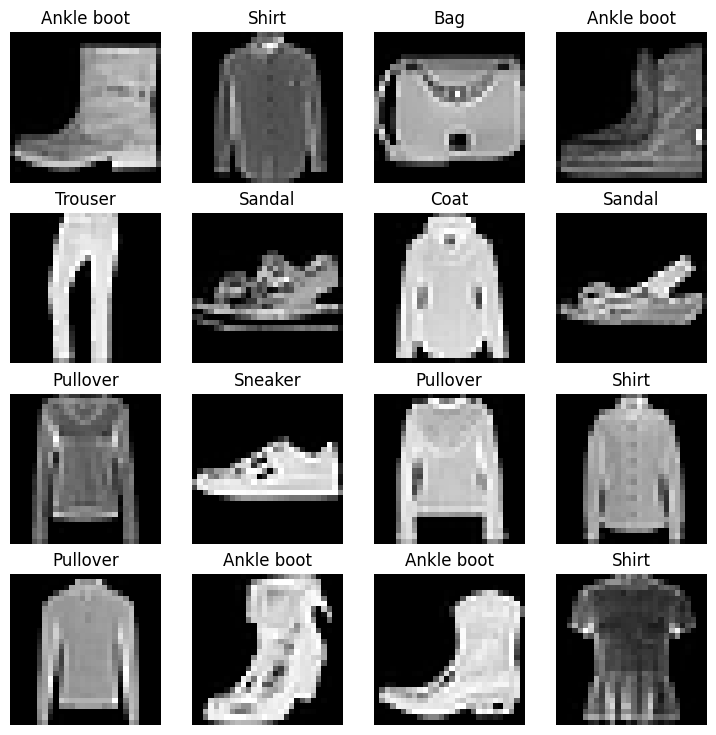

In [9]:
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_name[label])
    plt.axis(False);

#02: Preparing DataLoaders

A `DataLoader` in PyTorch is an iterator that provides an efficient way to load and process data in batches, especially useful for training deep learning models. It abstracts away much of the complexity of data handling, including:

*   **Batching**: Grouping multiple samples into a single batch for efficient computation.
*   **Shuffling**: Randomizing the order of samples to prevent the model from learning the order of data.
*   **Parallelism**: Loading data in parallel using multiple worker processes to avoid I/O bottlenecks.

### Major Steps to Use a DataLoader:

1.  **Create a Dataset**: First, you need a `torch.utils.data.Dataset` object. This object stores your samples and their corresponding labels. It needs to implement two methods: `__len__` (returns the number of samples in the dataset) and `__getitem__` (returns a sample and its label at a given index).
2.  **Instantiate DataLoader**: Once you have a Dataset, you can create a `DataLoader` instance by passing your dataset to it, along with parameters like `batch_size`, `shuffle`, and `num_workers`.
3.  **Iterate through DataLoader**: During training or evaluation, you can then iterate over the `DataLoader` to get batches of data, which are typically tensors ready for your model.

In [10]:
from torch.utils.data import DataLoader

batch_size = 32

train_dataloader = DataLoader(
    train_data,
    batch_size= batch_size,
    shuffle=True)

test_dataloader = DataLoader(
    test_data,
    batch_size = batch_size,
    shuffle=False)

print(f"the length of the train_dataloader is {len(train_dataloader)} & test_dataloader is {len(test_dataloader)}\n")
print(f"The train_dataloader is {train_dataloader} & test_dataloader is {test_dataloader}")


the length of the train_dataloader is 1875 & test_dataloader is 313

The train_dataloader is <torch.utils.data.dataloader.DataLoader object at 0x7e9cf67d5430> & test_dataloader is <torch.utils.data.dataloader.DataLoader object at 0x7e9cf56cf620>


In [11]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))

print(f"The shape of train_feature_batch is {train_features_batch.shape}")
print(f"The shape of train_feature_batch is {train_labels_batch.shape}")

The shape of train_feature_batch is torch.Size([32, 1, 28, 28])
The shape of train_feature_batch is torch.Size([32])


Image size: torch.Size([1, 28, 28])
Label: 6, label size: torch.Size([])


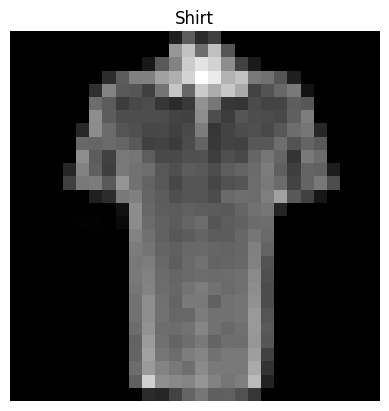

In [12]:
import matplotlib.pyplot as plt

#Seeing a sample
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_name[label])
plt.axis("Off");
print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

#03: Building Model_0

In [13]:
flatten_model = nn.Flatten()

x = train_features_batch[0]

output = flatten_model(x)

print(f"shape of x is {x.shape}")
print(f"shape of x after flattaeing {output.shape}")

shape of x is torch.Size([1, 28, 28])
shape of x after flattaeing torch.Size([1, 784])


In [14]:
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # neural networks like their inputs in vector form
            nn.Linear(in_features=input_shape, out_features=hidden_units), # in_features = number of features in a data sample (784 pixels)
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)


In [15]:
torch.manual_seed(42)
model_0 = FashionMNISTModelV0(
    input_shape=784,
    hidden_units=10,
    output_shape=len(class_name)
).to("cpu")

model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [16]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

### 03.1: Setup Loss Function and Optimizer for Model 0

In [17]:
# Import accuracy metric
from helper_functions import accuracy_fn # Note: could also use torchmetrics.Accuracy(task = 'multiclass', num_classes=len(class_names)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss() # this is also called "criterion"/"cost function" in some places
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

### 03.2: Helper Function: Track Training Time

In [18]:
from timeit import default_timer as Timer
def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
  total_time = end - start
  print(f'Train time on {device}: {total_time: .3f} seconds')
  return total_time

### 03.3: Training and Evaluation Loop for Model 0

In [19]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = Timer()

# Set the number of epochs (we'll keep this small for faster training times)
epochs = 3

# Create training and testing loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    ### Training
    train_loss = 0
    # Add a loop to loop through training batches
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()
        # 1. Forward pass
        y_pred = model_0(X)

        # 2. Calculate loss (per batch)
        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulatively add up the loss per epoch

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Print out how many samples have been seen
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    # Divide total train loss by length of train dataloader (average loss per batch per epoch)
    train_loss /= len(train_dataloader)

    ### Testing
    # Setup variables for accumulatively adding up loss and accuracy
    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            # 1. Forward pass
            test_pred = model_0(X)

            # 2. Calculate loss (accumulatively)
            test_loss += loss_fn(test_pred, y) # accumulatively add up the loss per epoch

            # 3. Calculate accuracy (preds need to be same as y_true)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

        # Calculations on test metrics need to happen inside torch.inference_mode()
        # Divide total test loss by length of test dataloader (per batch)
        test_loss /= len(test_dataloader)

        # Divide total accuracy by length of test dataloader (per batch)
        test_acc /= len(test_dataloader)

    ## Print out what's happening
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

# Calculate training time
train_time_end_on_cpu = Timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                           end=train_time_end_on_cpu,
                                           device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.59039 | Test loss: 0.50954, Test acc: 82.04%

Epoch: 1
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.47633 | Test loss: 0.47989, Test acc: 83.20%

Epoch: 2
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.45503 | Test loss: 0.47664, Test acc: 83.43%

Train time on cpu:  30.469 seconds


In [20]:
!nvidia-smi

Tue Jul 21 17:58:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### 00.2: Check for GPU Availability

In [21]:
torch.cuda.is_available()

True

In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

#04: Creating Model_1

### 04.1: Model Architecture V1 (with ReLU)

In [23]:
class FashionMNISTModelV1(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_shape),
        nn.ReLU()
    )

  def forward(self, X: torch.Tensor):
    return self.layer_stack(X)

### 04.2: Setup Loss Function and Optimizer for Model 1

In [24]:
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(
    input_shape = 784,
    hidden_units = 10,
    output_shape= len(class_name)
).to(device)
model_1


FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

In [25]:
next(model_1.parameters()).device

device(type='cuda', index=0)

### 04.3: Define Training and Testing Loop Functions

In [26]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_1.parameters(), lr = 0.01)

### 04.4: Training and Evaluation Loop for Model 1

In [27]:
def train_loop(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1)) # Go from logits -> pred labels

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_loop(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred = model(X)

            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Go from logits -> pred labels
            )

        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [28]:
torch.manual_seed(42)

train_time_start_on_gpu = Timer()

epochs = 3
for epoch in tqdm(range(epochs)):

  print(f"Epoch: {epoch} \n-----------")

  train_loop(model = model_1,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn)

  test_loop(data_loader=test_dataloader,
        model=model_1,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn
    )
train_time_end_on_gpu = Timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device
                                            )

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0 
-----------
Train loss: 1.42179 | Train accuracy: 54.29%
Test loss: 1.12168 | Test accuracy: 62.15%

Epoch: 1 
-----------
Train loss: 1.03359 | Train accuracy: 64.61%
Test loss: 1.00019 | Test accuracy: 64.48%

Epoch: 2 
-----------
Train loss: 0.95996 | Train accuracy: 66.05%
Test loss: 0.96338 | Test accuracy: 65.41%

Train time on cuda:  34.328 seconds


#Modle evaluation function

### 04.5: Model Evaluation Function

In [29]:
import torch

# Move values to device
torch.manual_seed(42)
def eval_model(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    accuracy_fn,
    device: torch.device = device
):
    loss, acc = 0, 0
    model.eval()
    # Move model to target device
    model.to(device)
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to the target device
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        # Scale loss and acc
        loss /= len(data_loader)
        acc /= len(data_loader)
    return {
        "model_name": model.__class__.__name__,
        "model_loss": loss.item(),
        "model_acc": acc,
    }

# Calculate model 1 results with device-agnostic code
model_1_results = eval_model(
    model=model_1,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.963383674621582,
 'model_acc': 65.40535143769968}

### 04.6: Evaluate Model 0 Results (for comparison)

In [30]:
model_0_results = eval_model(model=model_0, data_loader=test_dataloader,
                             device="cpu",
                             accuracy_fn=accuracy_fn,
                             loss_fn=loss_fn)
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

# 05: Model_3 (Convolutional Neural Network)

### 05.1: Model Architecture V2 (CNN)

## 05: Building Model_2 (Convolutional Neural Network)

In [31]:
class FashionMNISTModelV2(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.Block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size = 3,
                  stride=1,
                  padding = 1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2,
                     stride = 2)
    )
    self.Block_2 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= hidden_units * 7 * 7,
                  out_features=output_shape)
    )
  def forward(self, x: torch.Tensor):
    x = self.Block_1(x)
    # print(x.shape)
    x = self.Block_2(x)
    # print(x.shape)
    x = self.classifier(x)
    # print(x.shape)
    return x

torch.manual_seed(42)
model_2 = FashionMNISTModelV2(
    input_shape = 1,
    hidden_units = 10,
    output_shape= len(class_name)
).to(device)
model_2

# Define loss function and optimizer for model_2 immediately after its instantiation
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.01)

### 05.2: Setup Loss Function and Optimizer for Model 2

Creating optimzer & loss function for model_2

### 05.3: Note on Loss and Optimizer Definition

In [32]:
# The loss_fn and optimizer definitions are moved to cell D0E77GaxCdly to ensure they are always synchronized with model_2.
# This cell can now be removed or left empty, as the definitions are handled elsewhere.

### 05.4: Training and Evaluation Loop for Model 2

Training & Testing Loop

### 05.5: Comparing Model Results

In [33]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

start_train_time_model_2 = Timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch} --------")
  train_loop(data_loader= train_dataloader,
             model= model_2,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn= accuracy_fn,
             device = device)

  test_loop(data_loader=test_dataloader,
            model=model_2,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device
            )

train_time_end_model_2 = Timer()
total_train_time_model_2 = print_train_time(start=start_train_time_model_2,
                                            end = train_time_end_model_2,
                                            device = device)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0 --------
Train loss: 1.03785 | Train accuracy: 62.33%
Test loss: 0.62509 | Test accuracy: 76.89%

Epoch: 1 --------
Train loss: 0.54952 | Train accuracy: 80.00%
Test loss: 0.49840 | Test accuracy: 81.51%

Epoch: 2 --------
Train loss: 0.45589 | Train accuracy: 83.51%
Test loss: 0.44065 | Test accuracy: 84.22%

Train time on cuda:  39.277 seconds


In [34]:
model_2_results = eval_model(model = model_2,
                            data_loader= test_dataloader,
                             loss_fn= loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device)
print(model_2_results, "\n")
print(model_1_results, "\n")
model_0_results

{'model_name': 'FashionMNISTModelV2', 'model_loss': 0.44065359234809875, 'model_acc': 84.21525559105432} 

{'model_name': 'FashionMNISTModelV1', 'model_loss': 0.963383674621582, 'model_acc': 65.40535143769968} 



{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

In [35]:
import pandas as pd

compare_results = pd.DataFrame([model_0_results, model_1_results, model_2_results])
compare_results["Train_time"] = [total_train_time_model_0, total_train_time_model_1, total_train_time_model_2]

compare_results

,model_name,model_loss,model_acc,Train_time
0,FashionMNISTModelV0,0.476639,83.426518,30.468582
1,FashionMNISTModelV1,0.963384,65.405351,34.327530
2,FashionMNISTModelV2,0.440654,84.215256,39.277456


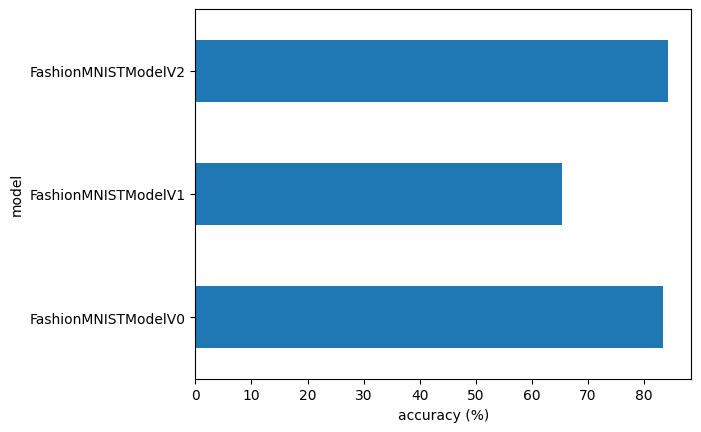

In [36]:
# Visualize our model results
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model");

# 06: Make and evaluate random predictions with best model

### 06.1: Define Prediction Function

## 06: Making and Evaluating Random Predictions with the Best Model

In [37]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Prepare sample
            sample = torch.unsqueeze(sample, dim=0).to(device) # Add an extra dimension and send sample to device

            # Forward pass (model outputs raw logit)
            pred_logit = model(sample)

            # Get prediction probability (logit -> prediction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 1, so can perform on dim=0)

            # Get pred_prob off GPU for further calculations
            pred_probs.append(pred_prob.cpu())

    # Stack the pred_probs to turn list into a tensor
    return torch.stack(pred_probs)

### 06.2: Selecting Random Test Samples

In [38]:
import random
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# View the first test sample shape and label
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_name[test_labels[0]]})")

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 2 (Pullover)


### 06.3: Generating Predictions

In [39]:
pred_probs = make_predictions(model=model_2,
                              data=test_samples)
pred_probs[:2]

tensor([[1.1675e-03, 8.9421e-02, 1.8877e-01, 2.6892e-05, 6.6131e-01, 4.9953e-05,
         5.8495e-02, 5.1459e-12, 7.6114e-04, 9.8125e-08],
        [5.0444e-05, 9.7157e-07, 9.0008e-07, 2.9385e-06, 8.6284e-07, 2.8673e-02,
         4.9632e-06, 1.4409e-01, 2.3290e-03, 8.2485e-01]])

### 06.4: Extracting Predicted Classes

In [40]:
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([4, 9, 7, 0, 7, 9, 3, 1, 5])

### 06.5: Visualizing Predictions

In [41]:
test_labels, pred_classes

([2, 9, 7, 0, 7, 9, 6, 1, 5], tensor([4, 9, 7, 0, 7, 9, 3, 1, 5]))

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

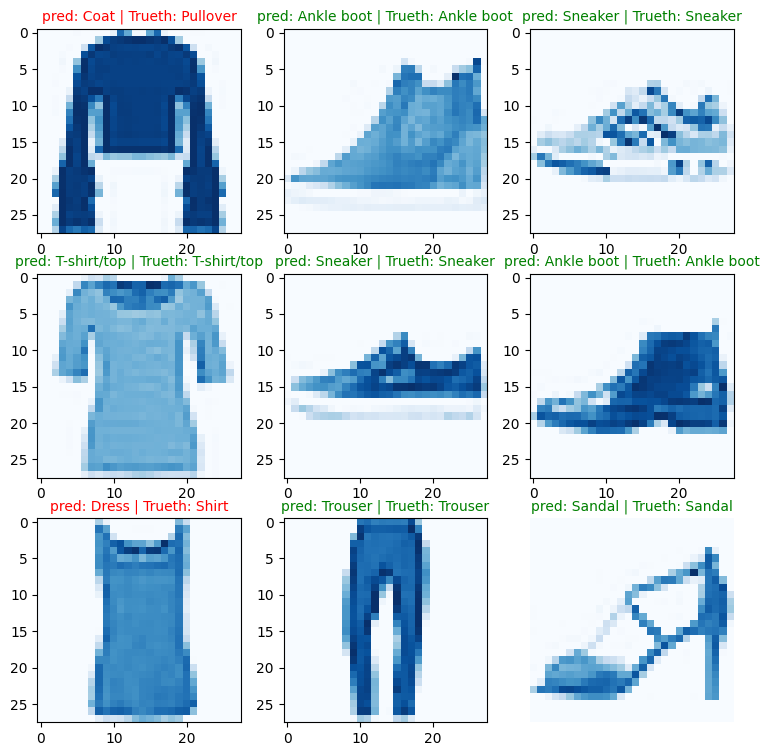

In [42]:
plt.figure(figsize=(9, 9))
nrow = 3
ncol = 3

for i, sample in enumerate(test_samples):

  plt.subplot(nrow, ncol, i+1)

  plt.imshow(sample.squeeze(), cmap = "Blues")

  pred_label = class_name[pred_classes[i]]

  truth_lable = class_name[test_labels[i]]

  title_text = f"pred: {pred_label} | Trueth: {truth_lable}"

  if pred_label == truth_lable:
    plt.title(title_text, fontsize = 10, c='g')
  else:
    plt.title(title_text, fontsize = 10, c='r')
plt.axis(False)

# 07: Making a confusion matrix for further prediction evaluation

### 07.1: Generating All Predictions

## 07: Creating a Confusion Matrix for Further Prediction Evaluation

In [43]:
y_preds = []
model_2.eval()

with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc = "Making predictions.."):

    X, y = X.to(device), y.to(device)

    y_logits = model_2(X)

    y_pred = torch.softmax(y_logits, dim = 1).argmax(dim = 1)

    y_preds.append(y_pred.cpu())
y_pred_tensor = torch.cat(y_preds)

Making predictions..:   0%|          | 0/313 [00:00<?, ?it/s]

### 07.2: Installing Required Libraries

In [44]:
!pip install torchmetrics mlxtend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.9 MB/s eta 0:00:00


### 07.3: Plotting the Confusion Matrix

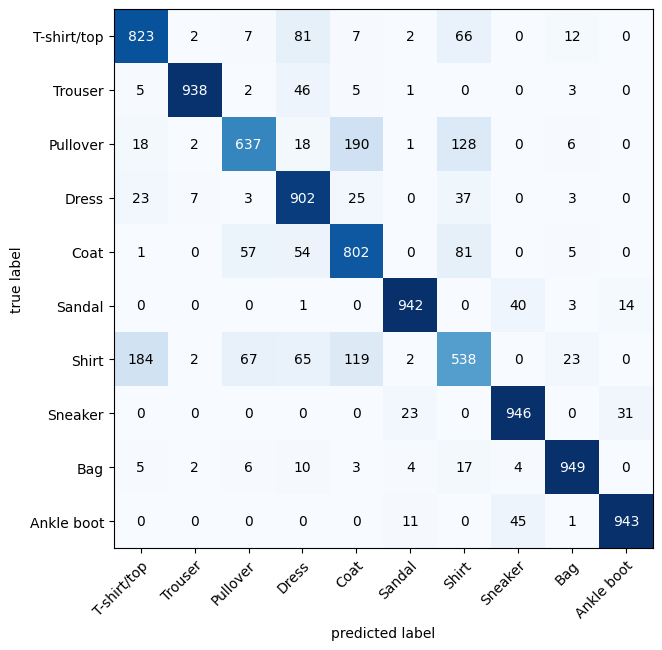

In [45]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. Setup confusion matrix instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(class_name), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

# 3. Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # matplotlib likes working with NumPy
    class_names=class_name, # turn the row and column labels into class names
    figsize=(10, 7)
);

# 08:Save and load best performing model

### 08.1: Defining Model Save Path

## 08: Saving and Loading the Best Performing Model

In [46]:
from pathlib import Path

Model_Path = Path("Models")
Model_Path.mkdir(parents = True,
                 exist_ok= True)

Model_Name = "03_PyTorch_Computer_Vision.pth"
Model_Save_Path = Model_Path / Model_Name

print(f"Model save path: {Model_Save_Path}")
torch.save(obj=model_2.state_dict(),
           f = Model_Save_Path)

Model save path: Models/03_PyTorch_Computer_Vision.pth


### 08.2: Instantiating and Loading the Saved Model

In [47]:
loaded_model_2 = FashionMNISTModelV2(
    input_shape=1,
    hidden_units=10,
    output_shape=len(class_name)
)

### 08.3: Moving Loaded Model to the Correct Device

In [48]:
loaded_model_2.load_state_dict(torch.load(f=Model_Save_Path))

<All keys matched successfully>

In [49]:
loaded_model_2 = loaded_model_2.to(device)

### 08.4: Evaluating the Loaded Model

In [50]:
torch.manual_seed(42)
loaded_model_2_results = eval_model(
    model =loaded_model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

loaded_model_2_results == model_2_results

True